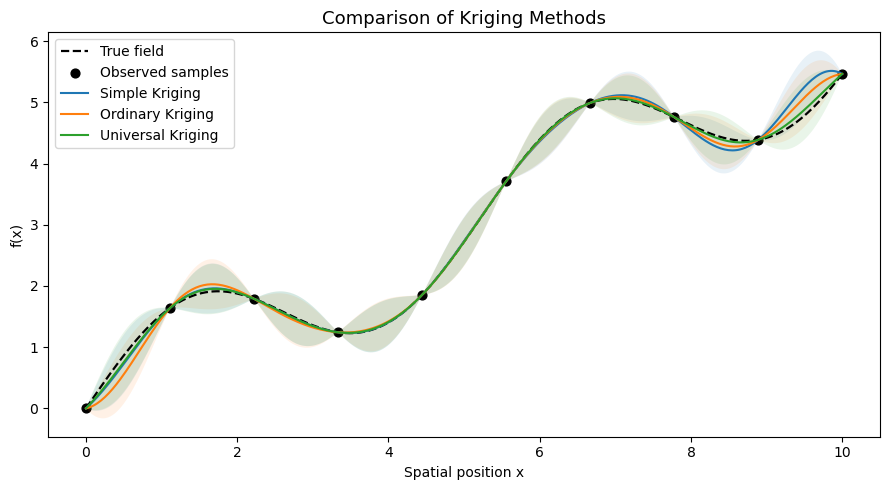

Visual interpretation:
  • Simple Kriging → assumes flat mean (reverts to 0 far away).
  • Ordinary Kriging → learns a single constant mean from data.
  • Universal Kriging → captures both the linear drift and local wiggles.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Ground truth and data
rng = np.random.default_rng(2)

def f_true(x):
    # A nonlinear function with a strong spatial trend
    return 0.6 * x + np.sin(1.2 * x)

# Fewer training points to highlight interpolation behavior
n_train = 10
X_train = np.linspace(0, 10, n_train)
y_train = f_true(X_train) + 0*rng.normal(scale=0.15, size=X_train.shape)
X_test = np.linspace(0, 10, 400)

# RBF (Gaussian) covariance
def rbf_cov(xa, xb, lengthscale, variance):
    xa = np.atleast_1d(xa)
    xb = np.atleast_1d(xb)
    d2 = (xa[:, None] - xb[None, :])**2
    return variance * np.exp(-0.5 * d2 / lengthscale**2)

# Simple Kriging
def simple_kriging(X_train, y_train, X_test, m0=0.0, lengthscale=1.0, variance=1.0, noise=1e-6):
    C = rbf_cov(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    C_inv = np.linalg.inv(C)
    c = rbf_cov(X_test, X_train, lengthscale, variance)
    k_star = variance * np.ones(len(X_test))
    alpha = C_inv @ (y_train - m0)
    mean = m0 + c @ alpha
    var = k_star - np.sum(c @ C_inv * c, axis=1)
    var = np.maximum(var, 1e-6)
    return mean, var

# Universal Kriging (general form)
def build_G(x, funcs):
    return np.column_stack([f(x) for f in funcs])

def universal_kriging(X_train, y_train, X_test, basis_funcs, lengthscale=1.0, variance=1.0, noise=1e-6):
    C = rbf_cov(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    c = rbf_cov(X_test, X_train, lengthscale, variance)
    C_inv = np.linalg.inv(C)

    G = build_G(X_train, basis_funcs)
    g_star = build_G(X_test, basis_funcs)

    GT_Cinv = G.T @ C_inv
    M = GT_Cinv @ G
    beta = np.linalg.solve(M, GT_Cinv @ y_train)
    r = y_train - G @ beta

    mean = g_star @ beta + c @ (C_inv @ r)
    k_star = variance * np.ones(len(X_test))
    base_var = k_star - np.sum(c * (C_inv @ c.T).T, axis=1)
    diff = g_star - (GT_Cinv @ c.T).T
    Minv = np.linalg.inv(M)
    extra = np.einsum('ij,jk,ik->i', diff, Minv, diff)
    var = base_var + extra
    return mean, np.maximum(var, 1e-6)

# Predictions for each type
# More distinct hyperparameters for clearer contrast
lengthscale = 0.9
variance = 1.2

# Simple Kriging (known mean)
mu_simple, var_simple = simple_kriging(X_train, y_train, X_test,
                                       m0=0.0, lengthscale=lengthscale, variance=variance)

# Ordinary Kriging (constant unknown mean)
mu_ok, var_ok = universal_kriging(X_train, y_train, X_test,
                                  [lambda x: np.ones_like(x)],
                                  lengthscale=lengthscale, variance=variance)

# Universal Kriging (linear trend)
mu_uk, var_uk = universal_kriging(X_train, y_train, X_test,
                                  [lambda x: np.ones_like(x), lambda x: x],
                                  lengthscale=lengthscale, variance=variance)

# Combined Comparison Plot
plt.figure(figsize=(9, 5))
plt.title("Comparison of Kriging Methods", fontsize=13)

# True field
plt.plot(X_test, f_true(X_test), 'k--', lw=1.6, label="True field")
plt.scatter(X_train, y_train, color='black', s=40, label="Observed samples")

# Predictions
plt.plot(X_test, mu_simple, lw=1.5, label="Simple Kriging")
plt.fill_between(X_test, mu_simple - 1.96*np.sqrt(var_simple),
                 mu_simple + 1.96*np.sqrt(var_simple), alpha=0.1)

plt.plot(X_test, mu_ok, lw=1.5, label="Ordinary Kriging")
plt.fill_between(X_test, mu_ok - 1.96*np.sqrt(var_ok),
                 mu_ok + 1.96*np.sqrt(var_ok), alpha=0.1)

plt.plot(X_test, mu_uk, lw=1.5, label="Universal Kriging")
plt.fill_between(X_test, mu_uk - 1.96*np.sqrt(var_uk),
                 mu_uk + 1.96*np.sqrt(var_uk), alpha=0.1)

plt.xlabel("Spatial position x")
plt.ylabel("f(x)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Quick Summary in Console
print("Visual interpretation:")
print("  • Simple Kriging → assumes flat mean (reverts to 0 far away).")
print("  • Ordinary Kriging → learns a single constant mean from data.")
print("  • Universal Kriging → captures both the linear drift and local wiggles.")

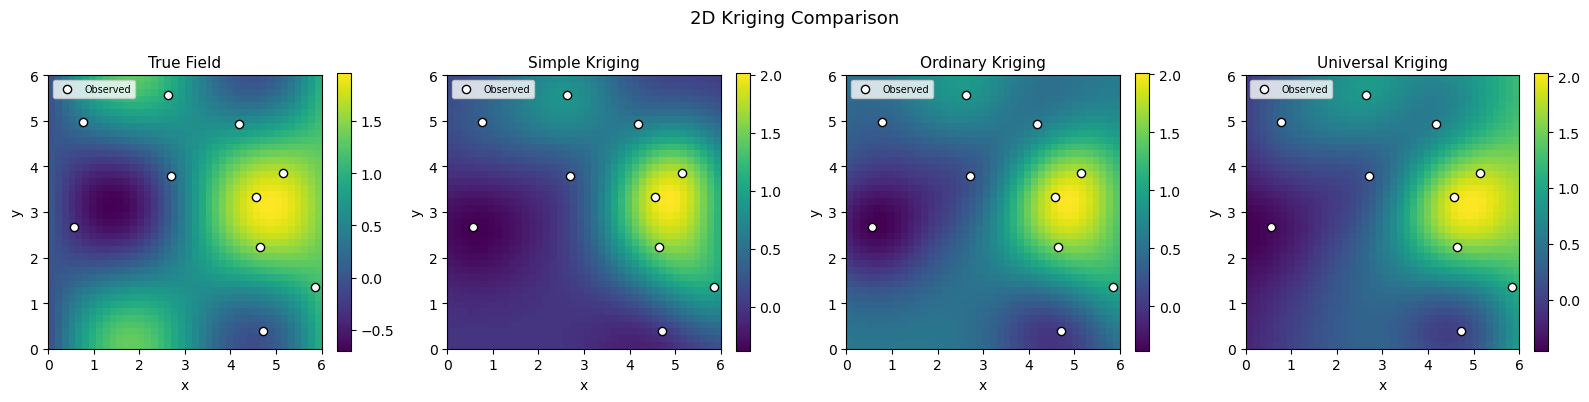

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Ground truth 2D field
def f_true(x, y):
    """Smooth function with a trend in x-direction"""
    return np.sin(x) * np.cos(y) + 0.2 * x

# Define grid
nx, ny = 40, 40
xv = np.linspace(0, 6, nx)
yv = np.linspace(0, 6, ny)
Xg, Yg = np.meshgrid(xv, yv)
F_true = f_true(Xg, Yg)

# Random sample points (observations)
rng = np.random.default_rng(42)
n_obs = 10
X_obs = rng.uniform(0, 6, n_obs)
Y_obs = rng.uniform(0, 6, n_obs)
Z_obs = f_true(X_obs, Y_obs) + rng.normal(scale=0.05, size=n_obs)

# Flatten grid for interpolation
XY_train = np.column_stack([X_obs, Y_obs])
XY_test = np.column_stack([Xg.ravel(), Yg.ravel()])

# RBF covariance (isotropic)
def rbf_cov_2d(Xa, Xb, lengthscale=1.0, variance=1.0):
    d2 = cdist(Xa, Xb, "sqeuclidean")
    return variance * np.exp(-0.5 * d2 / lengthscale**2)

# Simple Kriging (mean known)
def simple_kriging_2d(X_train, y_train, X_test, m0=0.0, lengthscale=1.0, variance=1.0, noise=1e-6):
    C = rbf_cov_2d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    C_inv = np.linalg.inv(C)
    c = rbf_cov_2d(X_test, X_train, lengthscale, variance)
    alpha = C_inv @ (y_train - m0)
    mean = m0 + c @ alpha
    k_star = variance * np.ones(len(X_test))
    var = k_star - np.sum(c @ C_inv * c, axis=1)
    return mean, np.maximum(var, 1e-8)

# Universal Kriging (general)
def build_G_2d(X, funcs):
    return np.column_stack([f(X[:, 0], X[:, 1]) for f in funcs])

def universal_kriging_2d(X_train, y_train, X_test, basis_funcs, lengthscale=1.0, variance=1.0, noise=1e-6):
    C = rbf_cov_2d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    c = rbf_cov_2d(X_test, X_train, lengthscale, variance)
    C_inv = np.linalg.inv(C)

    G = build_G_2d(X_train, basis_funcs)
    g_star = build_G_2d(X_test, basis_funcs)

    GT_Cinv = G.T @ C_inv
    M = GT_Cinv @ G
    beta = np.linalg.solve(M, GT_Cinv @ y_train)
    r = y_train - G @ beta

    mean = g_star @ beta + c @ (C_inv @ r)
    k_star = variance * np.ones(len(X_test))
    base_var = k_star - np.sum(c * (C_inv @ c.T).T, axis=1)
    diff = g_star - (GT_Cinv @ c.T).T
    Minv = np.linalg.inv(M)
    extra = np.einsum('ij,jk,ik->i', diff, Minv, diff)
    var = base_var + extra
    return mean, np.maximum(var, 1e-8)


# Predictions
lengthscale, variance = 1.0, 1.0
m0 = 0.0

mu_simple, var_simple = simple_kriging_2d(XY_train, Z_obs, XY_test, m0, lengthscale, variance)
mu_ok, var_ok = universal_kriging_2d(XY_train, Z_obs, XY_test, [lambda x, y: np.ones_like(x)], lengthscale, variance)
mu_uk, var_uk = universal_kriging_2d(XY_train, Z_obs, XY_test, [lambda x, y: np.ones_like(x), lambda x, y: x], lengthscale, variance)

# Reshape predictions into 2D grids
Z_simple = mu_simple.reshape(Xg.shape)
Z_ok = mu_ok.reshape(Xg.shape)
Z_uk = mu_uk.reshape(Xg.shape)

# Plot Results
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

titles = ["True Field", "Simple Kriging", "Ordinary Kriging", "Universal Kriging"]
fields = [F_true, Z_simple, Z_ok, Z_uk]

for ax, title, field in zip(axs, titles, fields):
    im = ax.imshow(field, origin='lower', extent=[0, 6, 0, 6], cmap='viridis')
    ax.scatter(X_obs, Y_obs, c='white', edgecolor='k', s=35, label='Observed')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.legend(loc='upper left', fontsize=7)

plt.suptitle("2D Kriging Comparison", fontsize=13)
plt.tight_layout()
plt.show()

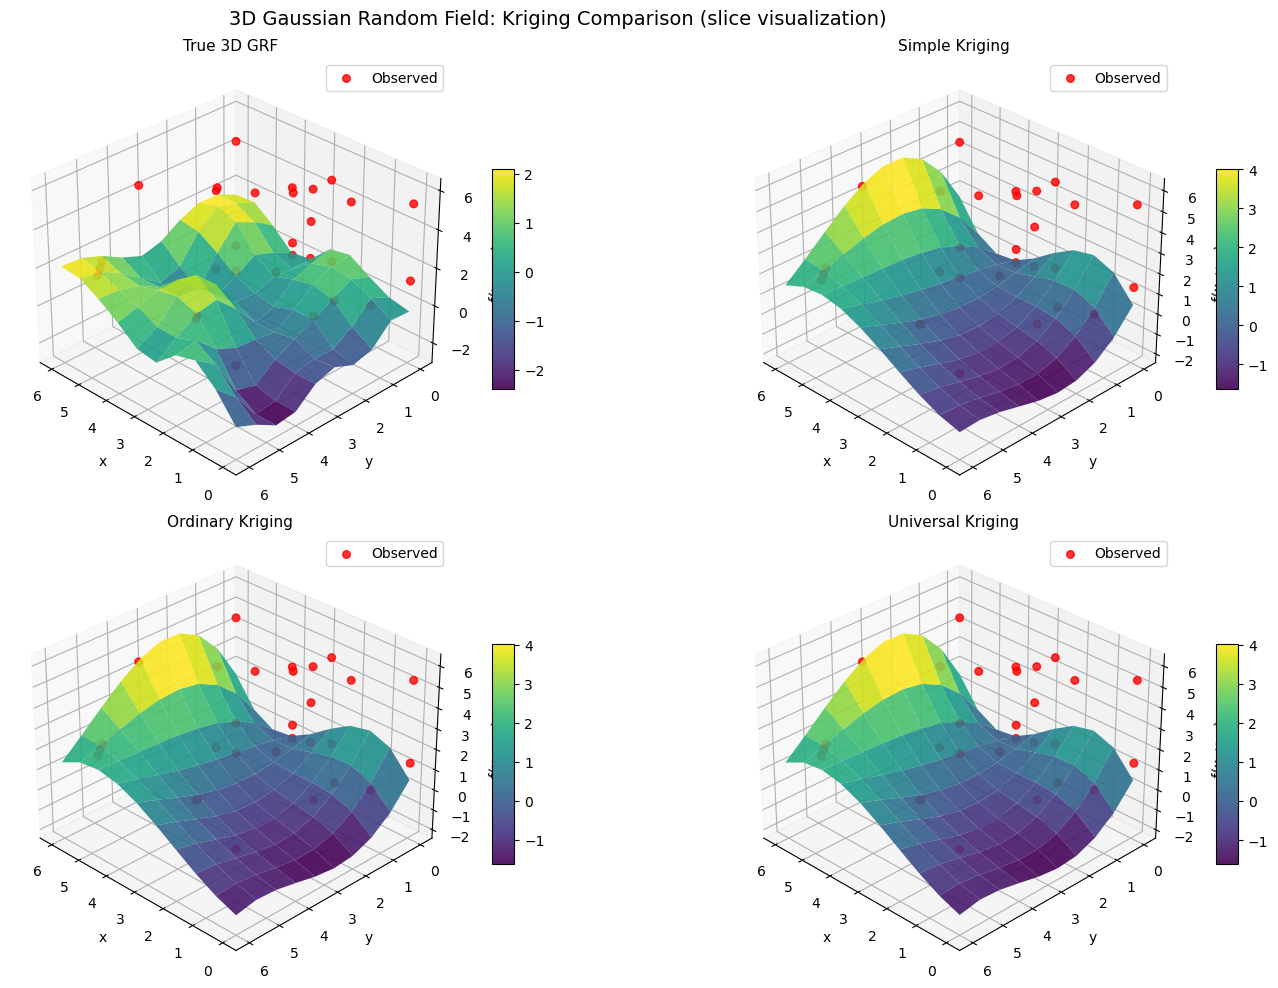

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Ground truth 3D Gaussian Random Field
def rbf_cov_3d(Xa, Xb, lengthscale=1.0, variance=1.0):
    """Isotropic RBF covariance for 3D points."""
    d2 = cdist(Xa, Xb, "sqeuclidean")
    return variance * np.exp(-0.5 * d2 / lengthscale**2)

# Define 3D grid (x, y, z)
nx, ny, nz = 10, 10, 10
xv = np.linspace(0, 6, nx)
yv = np.linspace(0, 6, ny)
zv = np.linspace(0, 6, nz)
Xg, Yg, Zg = np.meshgrid(xv, yv, zv, indexing="ij")
XYZ = np.column_stack([Xg.ravel(), Yg.ravel(), Zg.ravel()])

# Generate smooth Gaussian random field sample
rng = np.random.default_rng(0)
K = rbf_cov_3d(XYZ, XYZ, lengthscale=1.0, variance=1.0)
F_true = rng.multivariate_normal(np.zeros(len(XYZ)), K)
F_true = F_true.reshape(nx, ny, nz)

# Add a simple linear drift in x for interpretability
F_true += 0.15 * Xg

# Random sample points (observations)
n_obs = 30
idx_obs = rng.choice(len(XYZ), n_obs, replace=False)
XYZ_obs = XYZ[idx_obs]
V_obs = F_true.ravel()[idx_obs] + rng.normal(scale=0.05, size=n_obs)

# Kriging functions
def simple_kriging_3d(X_train, y_train, X_test, m0=0.0, lengthscale=1.0,
                      variance=1.0, noise=1e-6):
    C = rbf_cov_3d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    C_inv = np.linalg.inv(C)
    c = rbf_cov_3d(X_test, X_train, lengthscale, variance)
    alpha = C_inv @ (y_train - m0)
    mean = m0 + c @ alpha
    k_star = variance * np.ones(len(X_test))
    var = k_star - np.sum(c @ C_inv * c, axis=1)
    return mean, np.maximum(var, 1e-8)

def build_G(X, funcs):
    return np.column_stack([f(X[:, 0], X[:, 1], X[:, 2]) for f in funcs])

def universal_kriging_3d(X_train, y_train, X_test, basis_funcs, lengthscale=1.0,
                         variance=1.0, noise=1e-6):
    C = rbf_cov_3d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    c = rbf_cov_3d(X_test, X_train, lengthscale, variance)
    C_inv = np.linalg.inv(C)
    G = build_G(X_train, basis_funcs)
    g_star = build_G(X_test, basis_funcs)
    GT_Cinv = G.T @ C_inv
    M = GT_Cinv @ G
    beta = np.linalg.solve(M, GT_Cinv @ y_train)
    r = y_train - G @ beta
    mean = g_star @ beta + c @ (C_inv @ r)
    k_star = variance * np.ones(len(X_test))
    base_var = k_star - np.sum(c * (C_inv @ c.T).T, axis=1)
    diff = g_star - (GT_Cinv @ c.T).T
    Minv = np.linalg.inv(M)
    extra = np.einsum('ij,jk,ik->i', diff, Minv, diff)
    var = base_var + extra
    return mean, np.maximum(var, 1e-8)

# Predictions (evaluate on full 3D grid)
lengthscale, variance = 6.0, 3.0
m0 = 0.0

mu_simple, _ = simple_kriging_3d(XYZ_obs, V_obs, XYZ, m0, lengthscale, variance)
mu_ok, _ = universal_kriging_3d(XYZ_obs, V_obs, XYZ,
                                [lambda x, y, z: np.ones_like(x)], lengthscale, variance)
mu_uk, _ = universal_kriging_3d(XYZ_obs, V_obs, XYZ,
                                [lambda x, y, z: np.ones_like(x), lambda x, y, z: x],
                                lengthscale, variance)

# Reshape to 3D cubes
F_simple = mu_simple.reshape(nx, ny, nz)
F_ok = mu_ok.reshape(nx, ny, nz)
F_uk = mu_uk.reshape(nx, ny, nz)

# Visualization (3D slices)
slice_z = nz // 2  # middle z-slice
fields = [F_true, F_simple, F_ok, F_uk]
titles = ["True 3D GRF", "Simple Kriging", "Ordinary Kriging", "Universal Kriging"]

fig = plt.figure(figsize=(16, 10))
for i, (F, title) in enumerate(zip(fields, titles), 1):
    ax = fig.add_subplot(2, 2, i, projection="3d")
    surf = ax.plot_surface(Xg[:, :, slice_z], Yg[:, :, slice_z],
                           F[:, :, slice_z],
                           cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
    ax.scatter(XYZ_obs[:, 0], XYZ_obs[:, 1], XYZ_obs[:, 2],
               c="r", s=30, label="Observed", alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y, z)")
    ax.view_init(elev=30, azim=135)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    ax.legend(loc="upper right")

plt.suptitle("3D Gaussian Random Field: Kriging Comparison (slice visualization)", fontsize=14)
plt.tight_layout()
plt.show()


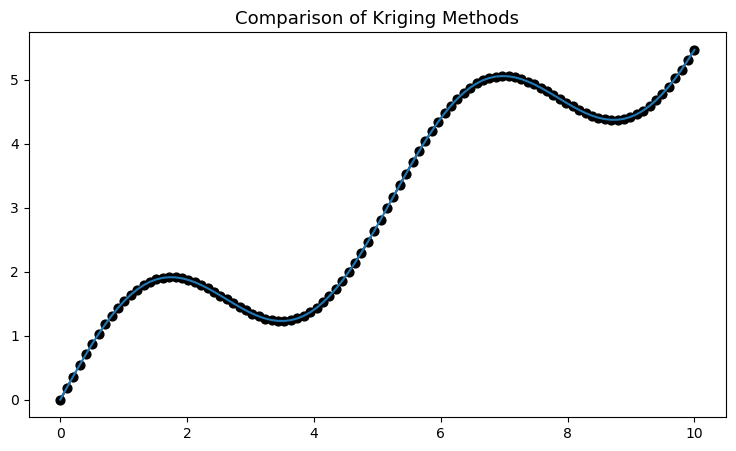

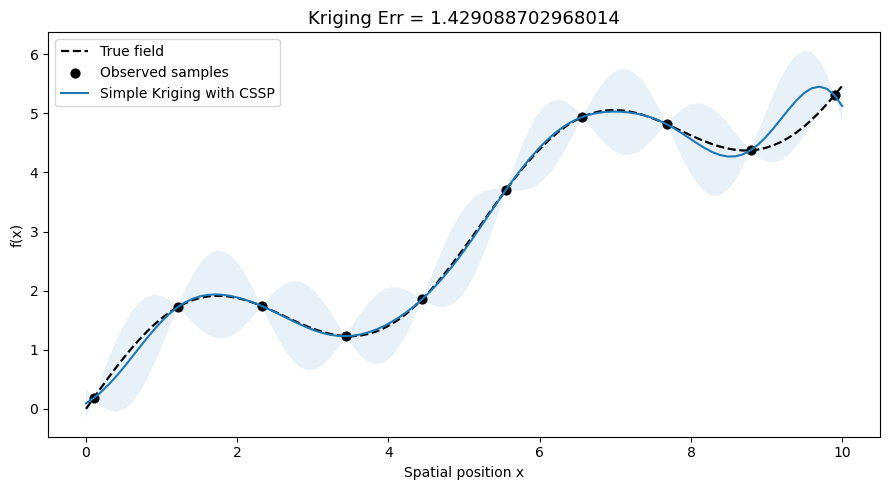

Visual interpretation:
  • Simple Kriging → assumes flat mean (reverts to 0 far away).
  • Ordinary Kriging → learns a single constant mean from data.


In [18]:
## Testing for subset selection

import numpy as np
import matplotlib.pyplot as plt
import scipy
from sklearn.utils.extmath import randomized_svd

# Ground truth and data
rng = np.random.default_rng(2)

def f_true(x):
    # A nonlinear function with a strong spatial trend
    return 0.6 * x + np.sin(1.2 * x)

    # t1 = 0.6 * x + np.sin(1.2 * x);
    # mask1 = (x >= np.pi) & (x <= 3*np.pi)
    # t1[mask1] = t1[mask1] + np.sin(4*x[mask1])
    # return t1

# Fewer training points to highlight interpolation behavior
n_train = 100
n_test = 100
X_train = np.linspace(0, 10, n_train)
y_train = f_true(X_train) + 0*rng.normal(scale=0.15, size=X_train.shape)
X_test = np.linspace(0, 10, n_test)

# RBF (Gaussian) covariance
def rbf_cov(xa, xb, lengthscale, variance):
    xa = np.atleast_1d(xa)
    xb = np.atleast_1d(xb)
    d2 = (xa[:, None] - xb[None, :])**2
    return variance * np.exp(-0.5 * d2 / lengthscale**2)

# Simple Kriging
def simple_kriging(X_train, y_train, X_test, m0=0.0, lengthscale=1.0, variance=1.0, noise=1e-6):
    C = rbf_cov(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    C_inv = np.linalg.inv(C)
    c = rbf_cov(X_test, X_train, lengthscale, variance)
    k_star = variance * np.ones(len(X_test))
    alpha = C_inv @ (y_train - m0)
    mean = m0 + c @ alpha
    var = k_star - np.sum(c @ C_inv * c, axis=1)
    var = np.maximum(var, 1e-6)
    return mean, var, C

# Universal Kriging (general form)
def build_G(x, funcs):
    return np.column_stack([f(x) for f in funcs])



# Predictions for each type
# More distinct hyperparameters for clearer contrast
lengthscale = 0.7
variance = 1

# Simple Kriging (known mean)
mu_simple, var_simple, C = simple_kriging(X_train, y_train, X_test,
                                       m0=0.0, lengthscale=lengthscale, variance=variance)

nsel = 10
U, s, Vh = randomized_svd(C, n_components=nsel, random_state=0)
_,_,p = scipy.linalg.qr(Vh, pivoting=True)
p = p[0:nsel]
#p = np.sort(p)

mu_simple2, var_simple2, _ = simple_kriging(X_train[p], y_train[p], X_test,
                                       m0=0.0, lengthscale=lengthscale, variance=variance)
err = 0
err = np.linalg.norm(mu_simple2 - y_train)


# Combined Comparison Plot
plt.figure(figsize=(9, 5))
plt.title("Comparison of Kriging Methods", fontsize=13)

# True field
plt.plot(X_test, f_true(X_test), 'k--', lw=1.6, label="True field")
plt.scatter(X_train, y_train, color='black', s=40, label="Observed samples")

# Predictions
plt.plot(X_test, mu_simple, lw=1.5, label="Simple Kriging")
plt.fill_between(X_test, mu_simple - 1.96*np.sqrt(var_simple),
                 mu_simple + 1.96*np.sqrt(var_simple), alpha=0.1)

plt.figure(figsize=(9, 5))
plt.title("Kriging Err = "+str(err), fontsize=13)

# True field
plt.plot(X_test, f_true(X_test), 'k--', lw=1.6, label="True field")
plt.scatter(X_train[p], y_train[p], color='black', s=40, label="Observed samples")

# Predictions
plt.plot(X_test, mu_simple2, lw=1.5, label="Simple Kriging with CSSP")
plt.fill_between(X_test, mu_simple2 - 1.96*np.sqrt(var_simple2), mu_simple2 + 1.96*np.sqrt(var_simple2), alpha=0.1)


plt.xlabel("Spatial position x")
plt.ylabel("f(x)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Quick Summary in Console
print("Visual interpretation:")
print("  • Simple Kriging → assumes flat mean (reverts to 0 far away).")
print("  • Ordinary Kriging → learns a single constant mean from data.")

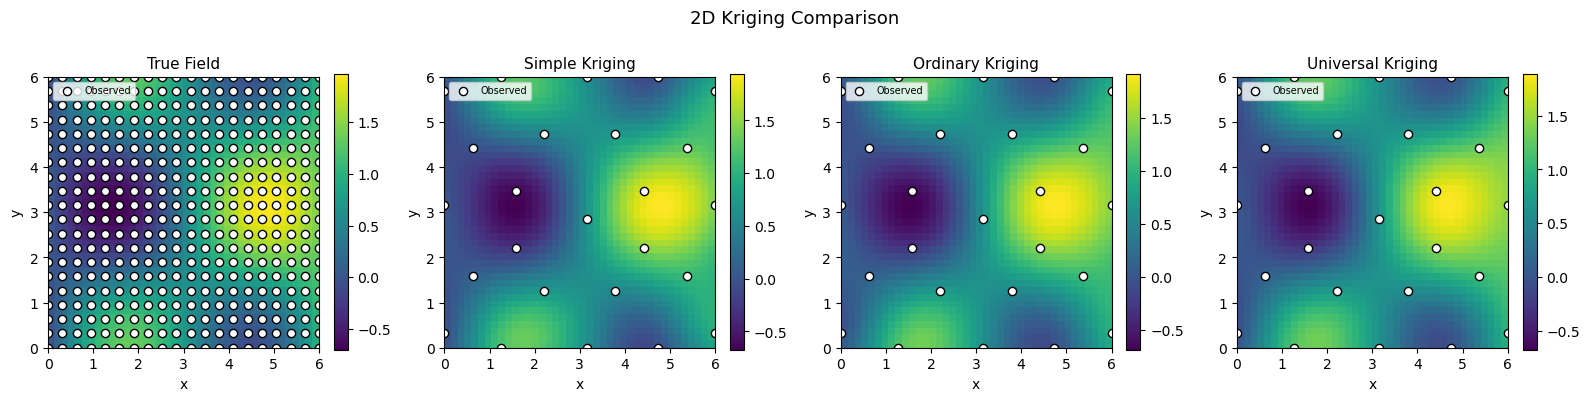

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import scipy
from sklearn.utils.extmath import randomized_svd

# Ground truth 2D field
def f_true(x, y):
    """Smooth function with a trend in x-direction"""
    return np.sin(x) * np.cos(y) + 0.2 * x

# Define grid
nx, ny = 40, 40
xv = np.linspace(0, 6, nx)
yv = np.linspace(0, 6, ny)
Xg, Yg = np.meshgrid(xv, yv)
F_true = f_true(Xg, Yg)

# Random sample points (observations)
rng = np.random.default_rng(42)
n_obs = 20
X_obs = np.linspace(0, 6, n_obs)
Y_obs = np.linspace(0, 6, n_obs)
X_obs, Y_obs = np.meshgrid(X_obs, Y_obs)
X_obs = X_obs.ravel()
Y_obs = Y_obs.ravel()
Z_obs = f_true(X_obs, Y_obs) + 0*rng.normal(scale=0.05, size=n_obs**2)

# Flatten grid for interpolation
XY_train = np.column_stack([X_obs, Y_obs])
XY_test = np.column_stack([Xg.ravel(), Yg.ravel()])

# RBF covariance (isotropic)
def rbf_cov_2d(Xa, Xb, lengthscale=1.0, variance=1.0):
    d2 = cdist(Xa, Xb, "sqeuclidean")
    return variance * np.exp(-0.5 * d2 / lengthscale**2)

# Simple Kriging (mean known)
def simple_kriging_2d(X_train, y_train, X_test, m0=0.0, lengthscale=1.0, variance=1.0, noise=1e-6):
    C = rbf_cov_2d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    C_inv = np.linalg.inv(C)
    c = rbf_cov_2d(X_test, X_train, lengthscale, variance)
    alpha = C_inv @ (y_train - m0)
    mean = m0 + c @ alpha
    k_star = variance * np.ones(len(X_test))
    var = k_star - np.sum(c @ C_inv * c, axis=1)
    return mean, np.maximum(var, 1e-8), C

# Universal Kriging (general)
def build_G_2d(X, funcs):
    return np.column_stack([f(X[:, 0], X[:, 1]) for f in funcs])

def universal_kriging_2d(X_train, y_train, X_test, basis_funcs, lengthscale=1.0, variance=1.0, noise=1e-6):
    C = rbf_cov_2d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    c = rbf_cov_2d(X_test, X_train, lengthscale, variance)
    C_inv = np.linalg.inv(C)

    G = build_G_2d(X_train, basis_funcs)
    g_star = build_G_2d(X_test, basis_funcs)

    GT_Cinv = G.T @ C_inv
    M = GT_Cinv @ G
    beta = np.linalg.solve(M, GT_Cinv @ y_train)
    r = y_train - G @ beta

    mean = g_star @ beta + c @ (C_inv @ r)
    k_star = variance * np.ones(len(X_test))
    base_var = k_star - np.sum(c * (C_inv @ c.T).T, axis=1)
    diff = g_star - (GT_Cinv @ c.T).T
    Minv = np.linalg.inv(M)
    extra = np.einsum('ij,jk,ik->i', diff, Minv, diff)
    var = base_var + extra
    return mean, np.maximum(var, 1e-8), C


# Predictions
lengthscale, variance = 1.0, 1.0
m0 = 0.0

mu_simple, var_simple, C_simple = simple_kriging_2d(XY_train, Z_obs, XY_test, m0, lengthscale, variance)
mu_ok, var_ok, C_ok = universal_kriging_2d(XY_train, Z_obs, XY_test, [lambda x, y: np.ones_like(x)], lengthscale, variance)
mu_uk, var_uk, C_uk = universal_kriging_2d(XY_train, Z_obs, XY_test, [lambda x, y: np.ones_like(x), lambda x, y: x], lengthscale, variance)

nsel = 25

U, s, Vh = randomized_svd(C_simple, n_components=nsel, random_state=0)
_,_,p = scipy.linalg.qr(Vh, pivoting=True)
p = np.sort(p[0:nsel])

'''
All p will be the same because C is the same.
U, s, Vh = randomized_svd(C_ok, n_components=nsel, random_state=0)
_,_,p = scipy.linalg.qr(Vh, pivoting=True)
p_ok = np.sort(p[0:nsel])

U, s, Vh = randomized_svd(C_uk, n_components=nsel, random_state=0)
_,_,p = scipy.linalg.qr(Vh, pivoting=True)
p_uk = np.sort(p[0:nsel])
'''

mu_simple, var_simple, _ = simple_kriging_2d(XY_train[p], Z_obs[p], XY_test, m0, lengthscale, variance)
mu_ok, var_ok, _ = universal_kriging_2d(XY_train[p], Z_obs[p], XY_test, [lambda x, y: np.ones_like(x)], lengthscale, variance)
mu_uk, var_uk, _ = universal_kriging_2d(XY_train[p], Z_obs[p], XY_test, [lambda x, y: np.ones_like(x), lambda x, y: x], lengthscale, variance)

# Reshape predictions into 2D grids
Z_simple = mu_simple.reshape(Xg.shape)
Z_ok = mu_ok.reshape(Xg.shape)
Z_uk = mu_uk.reshape(Xg.shape)

# Plot Results
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

titles = ["True Field", "Simple Kriging", "Ordinary Kriging", "Universal Kriging"]
fields = [F_true, Z_simple, Z_ok, Z_uk]
sels = [np.arange(n_obs**2),p,p,p]

for ax, title, field, sel in zip(axs, titles, fields, sels):
    im = ax.imshow(field, origin='lower', extent=[0, 6, 0, 6], cmap='viridis')
    ax.scatter(X_obs[sel], Y_obs[sel], c='white', edgecolor='k', s=35, label='Observed')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.legend(loc='upper left', fontsize=7)

plt.suptitle("2D Kriging Comparison", fontsize=13)
plt.tight_layout()
plt.show()

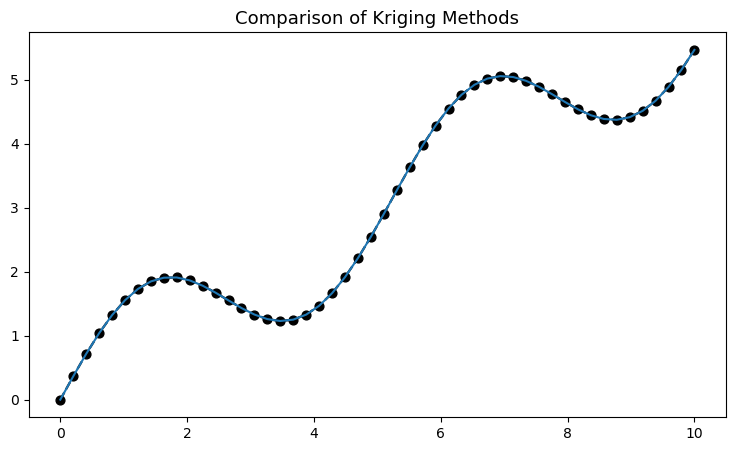

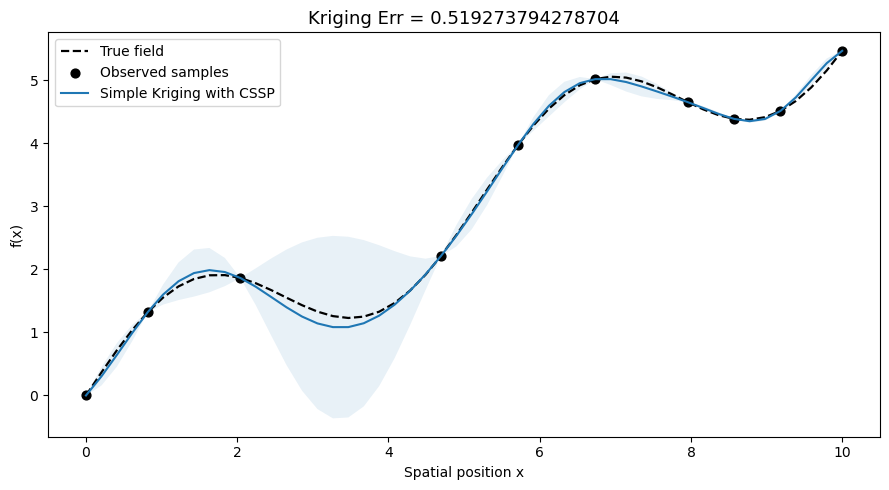

In [22]:
## Testing for subset selection

import numpy as np
import matplotlib.pyplot as plt
import scipy
from sklearn.utils.extmath import randomized_svd

# Ground truth and data
rng = np.random.default_rng(2)

def f_true(x):
    # A nonlinear function with a strong spatial trend
    t1 = 0.6 * x + np.sin(1.2 * x);

    # mask1 = (x >= np.pi) & (x <= 3*np.pi)
    # t1[mask1] = t1[mask1] + np.sin(4*x[mask1])

    return t1

# Fewer training points to highlight interpolation behavior
n_train = 50
X_train = np.linspace(0, 10, n_train)
y_train = f_true(X_train) + 0*rng.normal(scale=0.15, size=X_train.shape)
X_test = X_train

# RBF (Gaussian) covariance
def rbf_cov(xa, xb, lengthscale, variance):
    xa = np.atleast_1d(xa)
    xb = np.atleast_1d(xb)
    d2 = (xa[:, None] - xb[None, :])**2
    return variance * np.exp(-0.5 * d2 / lengthscale**2)

# Simple Kriging
def simple_kriging(X_train, y_train, X_test, m0=0.0, lengthscale=1.0, variance=1.0, noise=1e-6):
    C = rbf_cov(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    C_inv = np.linalg.inv(C)
    c = rbf_cov(X_test, X_train, lengthscale, variance)
    k_star = variance * np.ones(len(X_test))
    alpha = C_inv @ (y_train - m0)
    mean = m0 + c @ alpha
    var = k_star - np.sum(c @ C_inv * c, axis=1)
    var = np.maximum(var, 1e-6)
    return mean, var, C

# Universal Kriging (general form)
def build_G(x, funcs):
    return np.column_stack([f(x) for f in funcs])



# Predictions for each type
# More distinct hyperparameters for clearer contrast
lengthscale = 1.0
variance = 1

# Simple Kriging (known mean)
mu_simple, var_simple, C = simple_kriging(X_train, y_train, X_test,
                                       m0=0.0, lengthscale=lengthscale, variance=variance)

k = 10
p = np.array((0, n_train-1), dtype='int32')

for i in range(2, k):
  err = np.full((n_train), np.inf)
  for j in range(n_train):
    if j not in p:
      tp = np.append(p, j)
      mu_simple2, var_simple2, _ = simple_kriging(X_train[tp], y_train[tp], X_test, m0=0.0, lengthscale=lengthscale, variance=variance)
      err[j] = np.linalg.norm(mu_simple2 - y_train)

  p = np.append(p, np.argmin(err))


mu_simple2, var_simple2, _ = simple_kriging(X_train[p], y_train[p], X_test, m0=0.0, lengthscale=lengthscale, variance=variance)
err = 0
err = np.linalg.norm(mu_simple2 - y_train)

# Combined Comparison Plot
plt.figure(figsize=(9, 5))
plt.title("Comparison of Kriging Methods", fontsize=13)

# True field
plt.plot(X_train, y_train, 'k--', lw=1.6, label="True field")
plt.scatter(X_test, y_train, color='black', s=40, label="Observed samples")

# Predictions
plt.plot(X_test, mu_simple, lw=1.5, label="Simple Kriging")
plt.fill_between(X_test, mu_simple - 1.96*np.sqrt(var_simple), mu_simple + 1.96*np.sqrt(var_simple), alpha=0.1)

plt.figure(figsize=(9, 5))
plt.title("Kriging Err = "+str(err), fontsize=13)

# True field
plt.plot(X_test, f_true(X_test), 'k--', lw=1.6, label="True field")
plt.scatter(X_train[p], y_train[p], color='black', s=40, label="Observed samples")

# Predictions
plt.plot(X_test, mu_simple2, lw=1.5, label="Simple Kriging with CSSP")
plt.fill_between(X_test, mu_simple2 - 1.96*np.sqrt(var_simple2), mu_simple2 + 1.96*np.sqrt(var_simple2), alpha=0.1)


plt.xlabel("Spatial position x")
plt.ylabel("f(x)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
mu_simple

array([-2.03887041e-03,  3.65856302e-01,  7.26579198e-01,  1.02835564e+00,
        1.30324838e+00,  1.55991418e+00,  1.75598864e+00,  1.85357086e+00,
        1.87391814e+00,  1.87646760e+00,  1.88251982e+00,  1.83976255e+00,
        1.68824028e+00,  1.46899529e+00,  1.34394695e+00,  1.46655703e+00,
        1.80393581e+00,  2.09614873e+00,  2.03799672e+00,  1.55726754e+00,
        9.43211136e-01,  6.81600060e-01,  1.10108829e+00,  2.10835638e+00,
        3.22889735e+00,  3.92809394e+00,  3.97131050e+00,  3.56447552e+00,
        3.19281399e+00,  3.28982266e+00,  3.96348200e+00,  4.94116525e+00,
        5.74443372e+00,  5.97588192e+00,  5.55280699e+00,  4.75967630e+00,
        4.08666465e+00,  3.93733170e+00,  4.37385134e+00,  5.06651110e+00,
        5.50177405e+00,  5.33071318e+00,  4.62273741e+00,  3.83103521e+00,
        3.47295390e+00,  3.74950084e+00,  4.40093467e+00,  4.94395061e+00,
        5.15478953e+00,  5.45659576e+00])

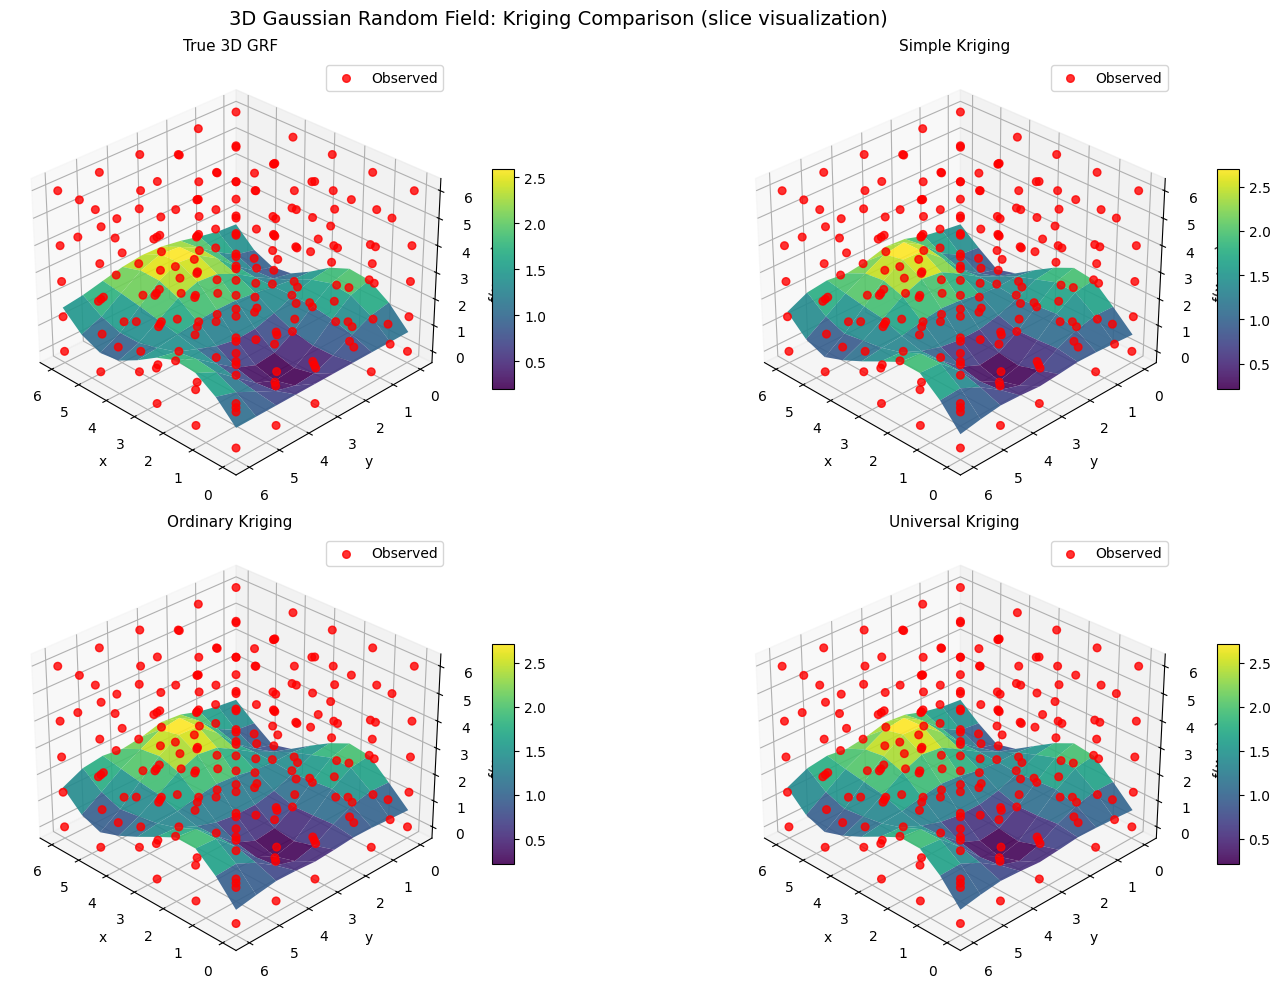

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import scipy
from sklearn.utils.extmath import randomized_svd
from scipy.sparse.linalg import LinearOperator

def randomized_svd_linear_operator(A, n_components, n_oversamples=10, n_iter=2, random_state=None):
    """
    Compute a randomized truncated SVD for a LinearOperator (or implicit matrix).
    Returns U, S, Vt.
    """
    rng = np.random.default_rng(random_state)
    n, m = A.shape
    n_random = n_components + n_oversamples

    # Step 1: Random test matrix
    Omega = rng.standard_normal(size=(m, n_random))

    # Step 2: Sample the range of A
    Y = A @ Omega

    # Step 3: Orthonormalize (QR)
    Q, _ = np.linalg.qr(Y, mode='reduced')

    # Step 4: Power iteration (optional, improves accuracy)
    for _ in range(n_iter):
        Z = A.T @ (A @ Q)
        Q, _ = np.linalg.qr(Z, mode='reduced')

    # Step 5: Project to smaller matrix
    B = Q.T @ (A @ np.eye(m))

    # Step 6: Compute SVD of small matrix
    U_tilde, S, Vt = np.linalg.svd(B, full_matrices=False)

    # Step 7: Map back to full space
    U = Q @ U_tilde
    return U[:, :n_components], S[:n_components], Vt[:n_components, :]

# Ground truth 3D Gaussian Random Field
def rbf_cov_3d(Xa, Xb, lengthscale=1.0, variance=1.0):
    """Isotropic RBF covariance for 3D points."""
    d2 = cdist(Xa, Xb, "sqeuclidean")
    return variance * np.exp(-0.5 * d2 / lengthscale**2)

def make_rbf_linear_operator(X, lengthscale=1.0, variance=1.0, batch_size=512):
    """
    Create a memory-efficient LinearOperator that represents the RBF kernel K(X, X).
    matvec() computes K @ v in chunks to avoid forming the full matrix.
    """
    n = X.shape[0]

    def matvec(v):
        result = np.zeros(n, dtype=float)
        for start in range(0, n, batch_size):
            stop = min(start + batch_size, n)
            # Compute one block of rows of K(X,X)
            Xi = X[start:stop]
            Ki = rbf_cov_3d(Xi, X, lengthscale, variance)  # (batch_size, n)
            result[start:stop] = (Ki @ v).reshape(-1)
        return result

    def matmat(M):
        result = np.zeros((n, M.shape[1]), dtype=float)
        for start in range(0, n, batch_size):
            stop = min(start + batch_size, n)
            # Compute one block of rows of K(X,X)
            Xi = X[start:stop]
            Ki = rbf_cov_3d(Xi, X, lengthscale, variance)  # (batch_size, n)
            result[start:stop, :] = (Ki @ M)
        return result

    return LinearOperator(
        dtype=np.float64,
        shape=(n, n),
        matvec=matvec,
        rmatvec=matvec,
        matmat=matmat,
        rmatmat=matmat
    )


# Define 3D grid (x, y, z)
nx, ny, nz = 10, 10, 10
xv = np.linspace(0, 6, nx)
yv = np.linspace(0, 6, ny)
zv = np.linspace(0, 6, nz)
Xg, Yg, Zg = np.meshgrid(xv, yv, zv, indexing="ij")
XYZ = np.column_stack([Xg.ravel(), Yg.ravel(), Zg.ravel()])

# Generate smooth Gaussian random field sample
rng = np.random.default_rng(0)
# K = rbf_cov_3d(XYZ, XYZ, lengthscale=1.0, variance=1.0)
F_true = np.sin(XYZ[:, 0]) * np.cos(XYZ[:, 1]) + 2*np.sin(2*XYZ[:, 2]) + 0.2 * XYZ[:, 0]
F_true = F_true.reshape(nx, ny, nz)

# Random sample points (observations)

n_obs = 200

Kop = make_rbf_linear_operator(XYZ, lengthscale=1.0, variance=1.0, batch_size=2)
U, s, Vh = randomized_svd_linear_operator(Kop, n_components=n_obs, n_oversamples=10, n_iter=1, random_state=0)

# U, s, Vh = randomized_svd(K, n_components=n_obs, random_state=0)
_,_,p = scipy.linalg.qr(Vh, pivoting=True)
idx_obs = p[0:n_obs]
XYZ_obs = XYZ[idx_obs]
V_obs = F_true.ravel()[idx_obs] + 0*rng.normal(scale=0.05, size=n_obs)

# Kriging functions
def simple_kriging_3d(X_train, y_train, X_test, m0=0.0, lengthscale=1.0,
                      variance=1.0, noise=1e-6):
    C = rbf_cov_3d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    C_inv = np.linalg.inv(C)
    c = rbf_cov_3d(X_test, X_train, lengthscale, variance)
    alpha = C_inv @ (y_train - m0)
    mean = m0 + c @ alpha
    k_star = variance * np.ones(len(X_test))
    var = k_star - np.sum(c @ C_inv * c, axis=1)
    return mean, np.maximum(var, 1e-8), C

def build_G(X, funcs):
    return np.column_stack([f(X[:, 0], X[:, 1], X[:, 2]) for f in funcs])

def universal_kriging_3d(X_train, y_train, X_test, basis_funcs, lengthscale=1.0,
                         variance=1.0, noise=1e-6):
    C = rbf_cov_3d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    c = rbf_cov_3d(X_test, X_train, lengthscale, variance)
    C_inv = np.linalg.inv(C)
    G = build_G(X_train, basis_funcs)
    g_star = build_G(X_test, basis_funcs)
    GT_Cinv = G.T @ C_inv
    M = GT_Cinv @ G
    beta = np.linalg.solve(M, GT_Cinv @ y_train)
    r = y_train - G @ beta
    mean = g_star @ beta + c @ (C_inv @ r)
    k_star = variance * np.ones(len(X_test))
    base_var = k_star - np.sum(c * (C_inv @ c.T).T, axis=1)
    diff = g_star - (GT_Cinv @ c.T).T
    Minv = np.linalg.inv(M)
    extra = np.einsum('ij,jk,ik->i', diff, Minv, diff)
    var = base_var + extra
    return mean, np.maximum(var, 1e-8), C

# Predictions (evaluate on full 3D grid)
lengthscale, variance = 1.0, 1.0
m0 = 0.0

mu_simple, _, C = simple_kriging_3d(XYZ_obs, V_obs, XYZ, m0, lengthscale, variance)
mu_ok, _, C= universal_kriging_3d(XYZ_obs, V_obs, XYZ,
                                [lambda x, y, z: np.ones_like(x)], lengthscale, variance)
mu_uk, _, C= universal_kriging_3d(XYZ_obs, V_obs, XYZ,
                                [lambda x, y, z: np.ones_like(x), lambda x, y, z: x],
                                lengthscale, variance)

# Reshape to 3D cubes
F_simple = mu_simple.reshape(nx, ny, nz)
F_ok = mu_ok.reshape(nx, ny, nz)
F_uk = mu_uk.reshape(nx, ny, nz)

# Visualization (3D slices)
slice_z = nz // 2  # middle z-slice
fields = [F_true, F_simple, F_ok, F_uk]
titles = ["True 3D GRF", "Simple Kriging", "Ordinary Kriging", "Universal Kriging"]

fig = plt.figure(figsize=(16, 10))
for i, (F, title) in enumerate(zip(fields, titles), 1):
    ax = fig.add_subplot(2, 2, i, projection="3d")
    surf = ax.plot_surface(Xg[:, :, slice_z], Yg[:, :, slice_z],
                           F[:, :, slice_z],
                           cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
    ax.scatter(XYZ_obs[:, 0], XYZ_obs[:, 1], XYZ_obs[:, 2],
               c="r", s=30, label="Observed", alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y, z)")
    ax.view_init(elev=30, azim=135)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    ax.legend(loc="upper right")

plt.suptitle("3D Gaussian Random Field: Kriging Comparison (slice visualization)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import scipy
from scipy.sparse.linalg import LinearOperator
from sklearn.neighbors import KDTree


def maxmin_ordering_fast(points, n_select=None):
    n_samples = points.shape[0]
    if n_samples == 0 or n_select is None:
        return []

    selected_indices = np.zeros(n_samples, dtype=bool)
    remaining_indices = np.ones(n_samples, dtype=bool)  # Boolean mask for remaining points

    # Start with the first point
    selected_indices[0] = True
    remaining_indices[0] = False

    # Initial distances from the first point
    distances = np.linalg.norm(points - points[0], axis=1)

    for i in range(1, n_select):
        # Pick the point with max distance
        furthest_point_index = np.argmax(distances * remaining_indices)  # ignore selected
        selected_indices[furthest_point_index] = True
        remaining_indices[furthest_point_index] = False

        # Update distances for remaining points using vectorized computation
        diff = points[remaining_indices] - points[furthest_point_index]
        new_dists = np.linalg.norm(diff, axis=1)
        distances[remaining_indices] = np.minimum(distances[remaining_indices], new_dists)

    return selected_indices


def rbf_cov_3d(Xa, Xb, lengthscale=1.0, variance=1.0):
    """Isotropic RBF covariance for 3D points."""
    d2 = cdist(Xa, Xb, "sqeuclidean")
    return variance * np.exp(-0.5 * d2 / lengthscale**2)

# Define 3D grid (x, y, z)
nx, ny, nz = 20, 20, 20
xv = np.linspace(0, 6, nx)
yv = np.linspace(0, 6, ny)
zv = np.linspace(0, 6, nz)
Xg, Yg, Zg = np.meshgrid(xv, yv, zv, indexing="ij")
XYZ = np.column_stack([Xg.ravel(), Yg.ravel(), Zg.ravel()])

# Generate smooth Gaussian random field sample
rng = np.random.default_rng(0)
F_true = np.sin(XYZ[:, 0]) * np.cos(XYZ[:, 1]) + 2*np.sin(2*XYZ[:, 2]) + 0.2 * XYZ[:, 0]
F_true = F_true.reshape(nx, ny, nz)

# Random sample points (observations)
n_obs = 150
idx_obs = maxmin_ordering_fast2(XYZ, n_select=n_obs)
XYZ_obs = XYZ[idx_obs]
V_obs = F_true.ravel()[idx_obs] + 0*rng.normal(scale=0.05, size=n_obs)

print("Done selection")

def simple_kriging_3d(X_train, y_train, X_test, m0=0.0, lengthscale=1.0,
                      variance=1.0, noise=1e-6):
    C = rbf_cov_3d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    C_inv = np.linalg.inv(C)
    c = rbf_cov_3d(X_test, X_train, lengthscale, variance)
    alpha = C_inv @ (y_train - m0)
    mean = m0 + c @ alpha
    k_star = variance * np.ones(len(X_test))
    var = k_star - np.sum(c @ C_inv * c, axis=1)
    return mean, np.maximum(var, 1e-8), C

def build_G(X, funcs):
    return np.column_stack([f(X[:, 0], X[:, 1], X[:, 2]) for f in funcs])

def universal_kriging_3d(X_train, y_train, X_test, basis_funcs, lengthscale=1.0,
                         variance=1.0, noise=1e-6):
    C = rbf_cov_3d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    c = rbf_cov_3d(X_test, X_train, lengthscale, variance)
    C_inv = np.linalg.inv(C)
    G = build_G(X_train, basis_funcs)
    g_star = build_G(X_test, basis_funcs)
    GT_Cinv = G.T @ C_inv
    M = GT_Cinv @ G
    beta = np.linalg.solve(M, GT_Cinv @ y_train)
    r = y_train - G @ beta
    mean = g_star @ beta + c @ (C_inv @ r)
    k_star = variance * np.ones(len(X_test))
    base_var = k_star - np.sum(c * (C_inv @ c.T).T, axis=1)
    diff = g_star - (GT_Cinv @ c.T).T
    Minv = np.linalg.inv(M)
    extra = np.einsum('ij,jk,ik->i', diff, Minv, diff)
    var = base_var + extra
    return mean, np.maximum(var, 1e-8), C

# Predictions (evaluate on full 3D grid)
lengthscale, variance = 1.0, 1.0
m0 = 0.0

mu_simple, _, C = simple_kriging_3d(XYZ_obs, V_obs, XYZ, m0, lengthscale, variance)
mu_ok, _, C= universal_kriging_3d(XYZ_obs, V_obs, XYZ,
                                [lambda x, y, z: np.ones_like(x)], lengthscale, variance)
mu_uk, _, C= universal_kriging_3d(XYZ_obs, V_obs, XYZ,
                                [lambda x, y, z: np.ones_like(x), lambda x, y, z: x],
                                lengthscale, variance)

# Reshape to 3D cubes
F_simple = mu_simple.reshape(nx, ny, nz)
F_ok = mu_ok.reshape(nx, ny, nz)
F_uk = mu_uk.reshape(nx, ny, nz)

# Visualization (3D slices)
slice_z = nz // 2  # middle z-slice
fields = [F_true, F_simple, F_ok, F_uk]
titles = ["True 3D GRF", "Simple Kriging", "Ordinary Kriging", "Universal Kriging"]

fig = plt.figure(figsize=(16, 10))
for i, (F, title) in enumerate(zip(fields, titles), 1):
    ax = fig.add_subplot(2, 2, i, projection="3d")
    surf = ax.plot_surface(Xg[:, :, slice_z], Yg[:, :, slice_z],
                           F[:, :, slice_z],
                           cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
    ax.scatter(XYZ_obs[:, 0], XYZ_obs[:, 1], XYZ_obs[:, 2],
               c="r", s=30, label="Observed", alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y, z)")
    ax.view_init(elev=30, azim=135)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    ax.legend(loc="upper right")

plt.suptitle("3D Gaussian Random Field: Kriging Comparison (slice visualization)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
from glob import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import scipy
!pip install pykrige
from pykrige.ok3d import OrdinaryKriging3D


def maxmin_ordering_fast(points, n_select=None):
    n_samples = points.shape[0]
    if n_samples == 0 or n_select is None:
        return []

    selected_indices = np.zeros(n_samples, dtype=bool)
    remaining_indices = np.ones(n_samples, dtype=bool)  # Boolean mask for remaining points

    # Start with the first point
    selected_indices[0] = True
    remaining_indices[0] = False

    # Initial distances from the first point
    distances = np.linalg.norm(points - points[0], axis=1)

    for i in range(1, n_select):
        # Pick the point with max distance
        print(i)
        furthest_point_index = np.argmax(distances * remaining_indices)  # ignore selected
        selected_indices[furthest_point_index] = True
        remaining_indices[furthest_point_index] = False

        # Update distances for remaining points using vectorized computation
        diff = points[remaining_indices] - points[furthest_point_index]
        new_dists = np.linalg.norm(diff, axis=1)
        distances[remaining_indices] = np.minimum(distances[remaining_indices], new_dists)

    return selected_indices

drive.mount('/content/gdrive')
save_dir = '/content/gdrive/My Drive/Colab Notebooks/ISABEL/'
file_paths = sorted(glob(os.path.join(save_dir, "*bin*")))

file_name = file_paths[17]
print(file_name)

with open(file_name, 'rb') as f:
    # Read the data as single precision floats (4 bytes each)
    data = np.fromfile(f, dtype=np.float32)

# Reshape the data to the desired dimensions (500, 500, 100)
data = data.reshape((100, 500, 500))
# plt.imshow(data[50, :, :])

nx, ny, nz = data.shape
xv = np.linspace(0, nx - 1, nx)
yv = np.linspace(0, ny - 1, ny)
zv = np.linspace(0, nz - 1, nz)
Xg, Yg, Zg = np.meshgrid(xv, yv, zv, indexing="ij")
XYZ = np.column_stack([Xg.ravel(), Yg.ravel(), Zg.ravel()])

n_obs = 100
idx_obs = maxmin_ordering_fast(XYZ, n_select=n_obs)
XYZ_obs = XYZ[idx_obs]
V_obs = data.ravel()[idx_obs]





Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/My Drive/Colab Notebooks/ISABEL/Uf48.bin.f32
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [ ]:

# Create an OrdinaryKriging object
OK = OrdinaryKriging3D(XYZ_obs[:, 0], XYZ_obs[:, 1], XYZ_obs[:, 2], V_obs, variogram_model='spherical')

# Interpolate over a grid or at specific points

xvq = 50.0
yvq = np.linspace(0, ny - 1, ny)
zvq = np.linspace(0, nz - 1, nz)
Xgq, Ygq, Zgq = np.meshgrid(xvq, yvq, zvq, indexing="ij")
grid_values, ss = OK.execute('points', Xgq.ravel(), Ygq.ravel(), Zgq.ravel())

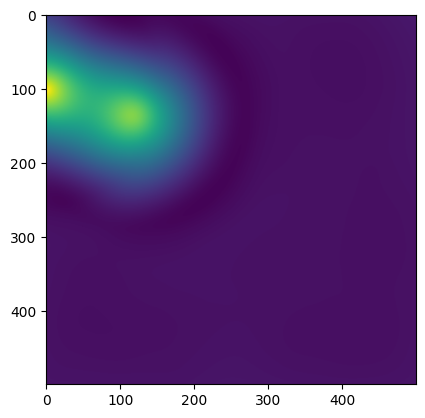

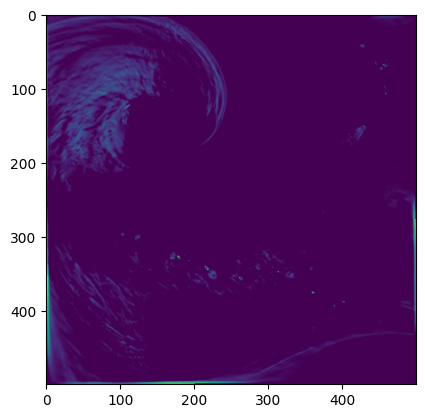

In [ ]:
plt.imshow(grid_values.data.reshape(ny, nz))

plt.figure()
plt.imshow(data[50, :, :])

In [ ]:
F_simple = mu_simple.reshape(nx, ny, nz)
F_ok = mu_ok.reshape(nx, ny, nz)
F_uk = mu_uk.reshape(nx, ny, nz)

# Visualization (3D slices)
slice_x = 50  # middle z-slice
fields = [F_true, F_simple, F_ok, F_uk]
titles = ["True 3D GRF", "Simple Kriging", "Ordinary Kriging", "Universal Kriging"]

fig = plt.figure(figsize=(16, 10))
for i, (F, title) in enumerate(zip(fields, titles), 1):
    ax = fig.add_subplot(2, 2, i, projection="3d")
    surf = ax.plot_surface(Xg[slice_x, :, :], Yg[slice_x, :, :],
                           F[slice_x, :, :],
                           cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
    ax.scatter(XYZ_obs[:, 0], XYZ_obs[:, 1], XYZ_obs[:, 2],
               c="r", s=30, label="Observed", alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y, z)")
    ax.view_init(elev=30, azim=135)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    ax.legend(loc="upper right")

plt.suptitle("3D Gaussian Random Field: Kriging Comparison (slice visualization)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def simple_kriging_3d(X_train, y_train, X_test, m0=0.0, lengthscale=1.0,
                      variance=1.0, noise=1e-6):
    C = rbf_cov_3d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    C_inv = np.linalg.inv(C)
    c = rbf_cov_3d(X_test, X_train, lengthscale, variance)
    alpha = C_inv @ (y_train - m0)
    mean = m0 + c @ alpha
    k_star = variance * np.ones(len(X_test))
    var = k_star - np.sum(c @ C_inv * c, axis=1)
    return mean, np.maximum(var, 1e-8), C

def build_G(X, funcs):
    return np.column_stack([f(X[:, 0], X[:, 1], X[:, 2]) for f in funcs])

def universal_kriging_3d(X_train, y_train, X_test, basis_funcs, lengthscale=1.0,
                         variance=1.0, noise=1e-6):
    C = rbf_cov_3d(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    c = rbf_cov_3d(X_test, X_train, lengthscale, variance)
    C_inv = np.linalg.inv(C)
    G = build_G(X_train, basis_funcs)
    g_star = build_G(X_test, basis_funcs)
    GT_Cinv = G.T @ C_inv
    M = GT_Cinv @ G
    beta = np.linalg.solve(M, GT_Cinv @ y_train)
    r = y_train - G @ beta
    mean = g_star @ beta + c @ (C_inv @ r)
    k_star = variance * np.ones(len(X_test))
    base_var = k_star - np.sum(c * (C_inv @ c.T).T, axis=1)
    diff = g_star - (GT_Cinv @ c.T).T
    Minv = np.linalg.inv(M)
    extra = np.einsum('ij,jk,ik->i', diff, Minv, diff)
    var = base_var + extra
    return mean, np.maximum(var, 1e-8), C

# Predictions (evaluate on full 3D grid)
lengthscale, variance = 1.0, 1.0
m0 = 0.0

mu_simple, _, C = simple_kriging_3d(XYZ_obs, V_obs, XYZ, m0, lengthscale, variance)
mu_ok, _, C= universal_kriging_3d(XYZ_obs, V_obs, XYZ,
                                [lambda x, y, z: np.ones_like(x)], lengthscale, variance)
mu_uk, _, C= universal_kriging_3d(XYZ_obs, V_obs, XYZ,
                                [lambda x, y, z: np.ones_like(x), lambda x, y, z: x],
                                lengthscale, variance)

# Reshape to 3D cubes
F_simple = mu_simple.reshape(nx, ny, nz)
F_ok = mu_ok.reshape(nx, ny, nz)
F_uk = mu_uk.reshape(nx, ny, nz)

# Visualization (3D slices)
slice_x = 50  # middle z-slice
fields = [F_true, F_simple, F_ok, F_uk]
titles = ["True 3D GRF", "Simple Kriging", "Ordinary Kriging", "Universal Kriging"]

fig = plt.figure(figsize=(16, 10))
for i, (F, title) in enumerate(zip(fields, titles), 1):
    ax = fig.add_subplot(2, 2, i, projection="3d")
    surf = ax.plot_surface(Xg[slice_x, :, :], Yg[slice_x, :, :],
                           F[slice_x, :, :],
                           cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
    ax.scatter(XYZ_obs[:, 0], XYZ_obs[:, 1], XYZ_obs[:, 2],
               c="r", s=30, label="Observed", alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y, z)")
    ax.view_init(elev=30, azim=135)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    ax.legend(loc="upper right")

plt.suptitle("3D Gaussian Random Field: Kriging Comparison (slice visualization)", fontsize=14)
plt.tight_layout()
plt.show()